In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.20.0
Libraries imported successfully!


In [2]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Dataset loaded successfully!")
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully!
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


In [3]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Training pixel range:", x_train.min(), "to", x_train.max())
print("Testing pixel range:", x_test.min(), "to", x_test.max())

Training pixel range: 0.0 to 1.0
Testing pixel range: 0.0 to 1.0


In [4]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


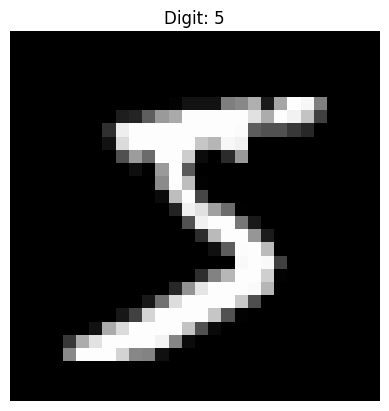

In [5]:
plt.imshow(x_train[0].reshape(28, 28), cmap='gray')
plt.title(f"Digit: {y_train[0]}")
plt.axis('off')
plt.show()

In [6]:
from tensorflow.keras import models, layers

model = models.Sequential([

    # Convolutional layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),

    # Pooling layer
    layers.MaxPooling2D((2, 2)),

    # Second convolutional layer
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Second pooling layer
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into a single vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Output layer - 10 digits
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [8]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 57ms/step - accuracy: 0.9491 - loss: 0.1701 - val_accuracy: 0.9863 - val_loss: 0.0497
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 59ms/step - accuracy: 0.9851 - loss: 0.0485 - val_accuracy: 0.9887 - val_loss: 0.0402
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - accuracy: 0.9898 - loss: 0.0340 - val_accuracy: 0.9873 - val_loss: 0.0438
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 59ms/step - accuracy: 0.9921 - loss: 0.0254 - val_accuracy: 0.9908 - val_loss: 0.0346
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.9943 - loss: 0.0185 - val_accuracy: 0.9907 - val_loss: 0.0334


In [9]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9911 - loss: 0.0274

Test Loss: 0.02737630344927311
Test Accuracy: 0.991100013256073
Test Accuracy: 99.11%


In [10]:
y_pred_prob = model.predict(x_test)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred[:10])
print("First 10 actual labels:", y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Predictions generated successfully!
First 10 predictions: [7 2 1 0 4 1 4 9 5 9]
First 10 actual labels: [7 2 1 0 4 1 4 9 5 9]


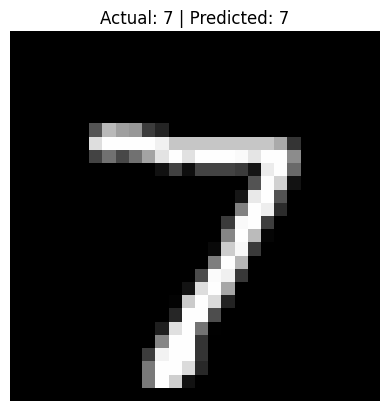

In [11]:
index = 0

plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
plt.title(
    f"Actual: {y_test[index]} | Predicted: {y_pred[index]}"
)
plt.axis('off')
plt.show()

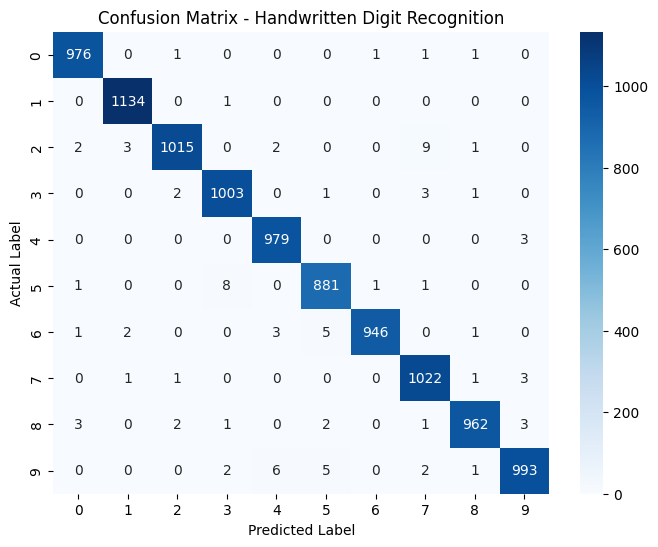

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Handwritten Digit Recognition")
plt.show()

In [13]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=[str(i) for i in range(10)]
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.98      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



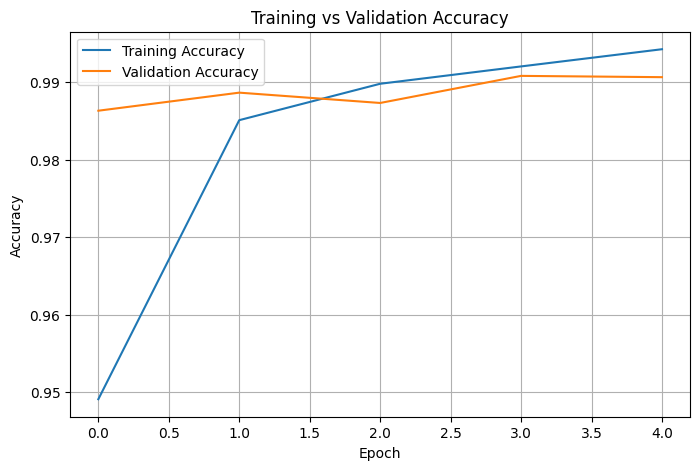

In [14]:
# Training and Validation Accuracy

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

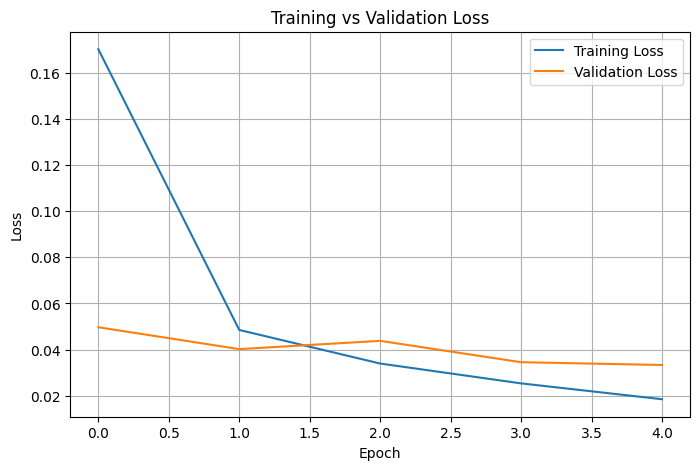

In [15]:
# Training and Validation Loss

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

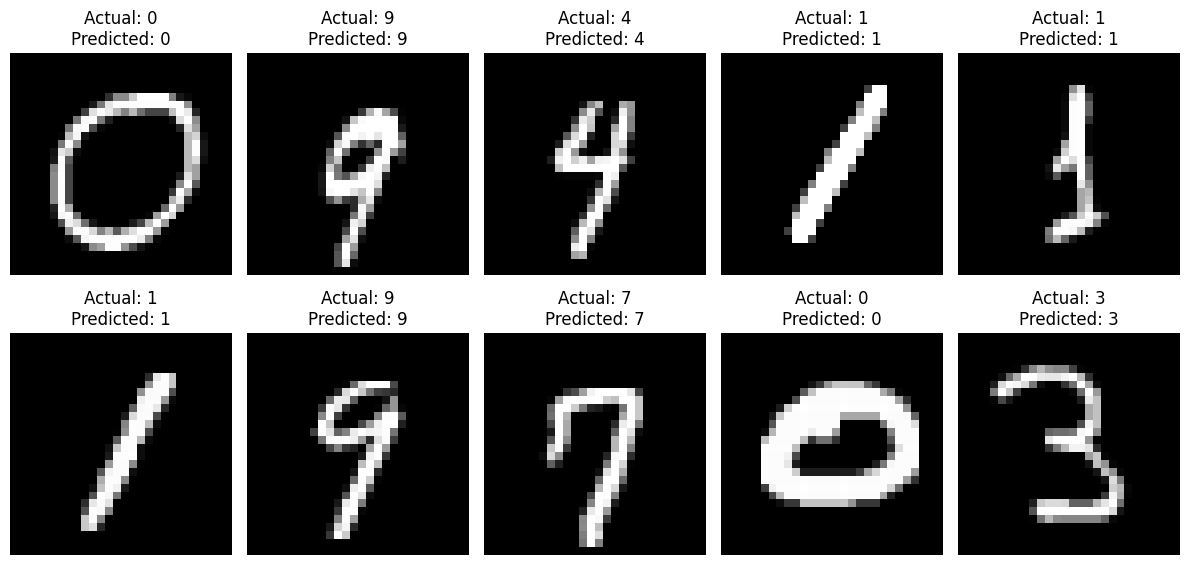

In [16]:
# Test the model on 10 random images

random_indices = np.random.choice(len(x_test), 10, replace=False)

plt.figure(figsize=(12, 6))

for i, index in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
    plt.title(
        f"Actual: {y_test[index]}\nPredicted: {y_pred[index]}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()